# Curso: Redes Neurais para Processamento de Linguagem Natural

Prof. [Denilson Alves Pereira](https://sites.google.com/ufla.br/denilsonpereira) <br>
Departamento de Ciência da Computação (DCC) <br>
Instituto de Ciências Exatas e Tecnológicas (ICET) <br> 
Universidade Federal de Lavras (UFLA)

Nome: Iara Campos Rodrigues

# Atividade Prática 04

**Tempo estimado para execução**: 3 horas

Versão: Julho, 2024

## Projeto Final

O objetivo da atividade é desenvolver um projeto prático livre utilizando o conhecimento adquirido no curso. Você deve escolher um *dataset* para um problema envolvendo redes neurais recorrentes ou Transformer (preferencialmente), ler e efetuar o pré-processamento desse conjunto de dados, configurar uma rede neural para efetuar o processamento ou carregar um modelo pré-treinado, e efetuar os pós-processamentos, se necessários. Avalie a predição no conjunto de teste. Você deve avaliar diversas configurações para a sua rede neural, de forma a obter um resultado satisfatório. Verifique na literatura os melhores resultados obtidos com o *dataset*, se você estiver usando um *dataset* público.

Para o *dataset*, escolha uma das opções abaixo:
- um dataset que você esteja trabalhando em um projeto pessoal ou da sua empresa;
- um dataset público.

Existem diversos *datasets* públicos disponíveis na Web. A plataforma *Hugging Face* (https://huggingface.co/) é uma das principais fontes.
Ela é uma plataforma colaborativa, onde os usuários podem compartilhar modelos, datasets e aplicações.

#### Importante:
Documente cada etapa do seu código. Crie céluas de *Markdown* com textos explicativos e links para referências. Adicione comentários ao seu código.


## Classificação de Sentimentos em Comentários de E-commerce Brasileiro Utilizando Modelos Transformer
O objetivo deste projeto é desenvolver um classificador de sentimentos a partir dos comentários (reviews) presentes no Brazilian E-Commerce Public Dataset by Olist, um conjunto de dados reais que reúne mais de 100 mil pedidos realizados entre 2016 e 2018 em marketplaces brasileiros. Este dataset inclui informações detalhadas sobre cada pedido, como status, pagamento, frete, atributos do produto e, especialmente, avaliações escritas pelos clientes após a entrega.

A proposta é aplicar técnicas de Processamento de Linguagem Natural (PLN) utilizando modelos do tipo Transformer, com foco na análise e classificação dos sentimentos expressos nas avaliações textuais. O modelo será treinado para classificar os comentários como **positivos**, **neutros** ou **negativos**, de forma a automatizar a leitura e interpretação do feedback dos clientes, fornecendo uma ferramenta útil para avaliar a experiência de compra na plataforma.


Dataset: (https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

## Importando as bibliotecas

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import tensorflow as tf
from transformers import TFBertForSequenceClassification

c:\Users\iarac\OneDrive\Documentos\Comp Sci\PLN\notebooks-aula\notebooks-aula\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\iarac\OneDrive\Documentos\Comp Sci\PLN\notebooks-aula\notebooks-aula\env\Lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [5]:
#Faz leitura do CSV
reviews=pd.read_csv('./data/olist_order_reviews_dataset.csv')
#Imprime primeiras linhas
reviews.head()


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [6]:

#Pegando colunas relevantes
reviews = reviews[['review_comment_message', 'review_score']]

#Remove dados faltantes
reviews=reviews.dropna()



## EDA (Análise Exploratória)

In [7]:

#Imprime os comentarios das avaliações
reviews.review_comment_message.values


array(['Recebi bem antes do prazo estipulado.',
       'Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa',
       'aparelho eficiente. no site a marca do aparelho esta impresso como 3desinfector e ao chegar esta com outro nome...atualizar com a marca correta uma vez que é o mesmo aparelho',
       ...,
       'O produto não foi enviado com NF, não existe venda sem NF, com certeza fico no aguardo do envio da NF podendo ser por e-mail.',
       'Excelente mochila, entrega super rápida. Super recomendo essa loja!',
       'meu produto chegou e ja tenho que devolver, pois está com defeito , não segurar carga'],
      dtype=object)

C:\Users\iarac\AppData\Local\Temp\ipykernel_18040\1015805156.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=score_counts.index, y=score_counts.values, palette="viridis")


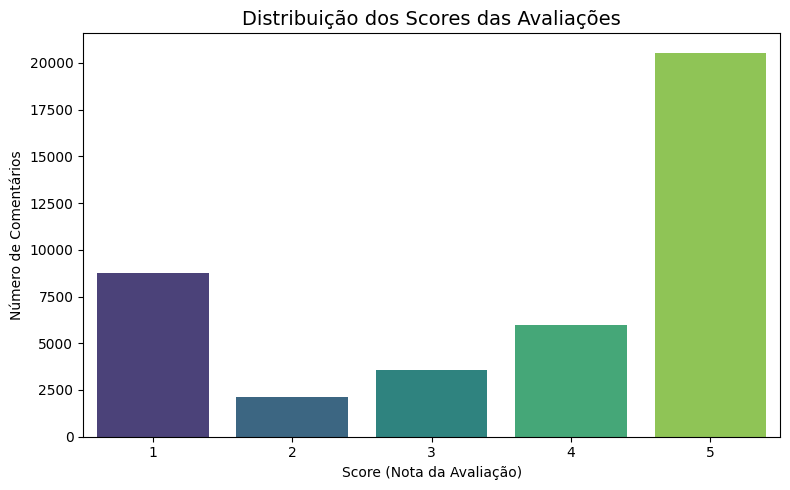

In [8]:
# Garante que os scores sejam inteiros
reviews['review_score'] = reviews['review_score'].astype(int)

# Define score
score_counts = reviews['review_score'].value_counts().sort_index().reindex([1, 2, 3, 4, 5], fill_value=0)

# Gráfico
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=score_counts.index, y=score_counts.values, palette="viridis")

# Títulos e rótulos
plt.title("Distribuição dos Scores das Avaliações", fontsize=14)
plt.xlabel("Score (Nota da Avaliação)")
plt.ylabel("Número de Comentários")
ax.set_xticks([0, 1, 2, 3, 4])  # Índices das barras
ax.set_xticklabels([1, 2, 3, 4, 5])  # Rótulos que devem aparecer

plt.tight_layout()
plt.show()

In [9]:
print(reviews['review_score'].value_counts())


review_score
5    20554
1     8745
4     5976
3     3557
2     2145
Name: count, dtype: int64


A distribuição dos scores revela uma concentração significativa nas extremidades — especialmente nas avaliações com notas 1 e 5 — sugerindo uma tendência à polarização nas experiências dos consumidores, com predominância de avaliações extremamente negativas ou extremamente positivas.

In [10]:
print("Média:", reviews['review_score'].mean())
print("Mediana:", reviews['review_score'].median())

Média: 3.66986358200942
Mediana: 5.0


Média: ~3,67
Isso indica que, em geral, as avaliações têm uma tendência levemente positiva, mas estão longe de serem unânimes. Ou seja, há bastante variabilidade.

Mediana: ~ 5.0
Isso mostra que mais da metade dos comentários deram nota máxima, mas há um volume expressivo de notas muito baixas (1), o que puxa a média para baixo

### Nuvem de palavras 

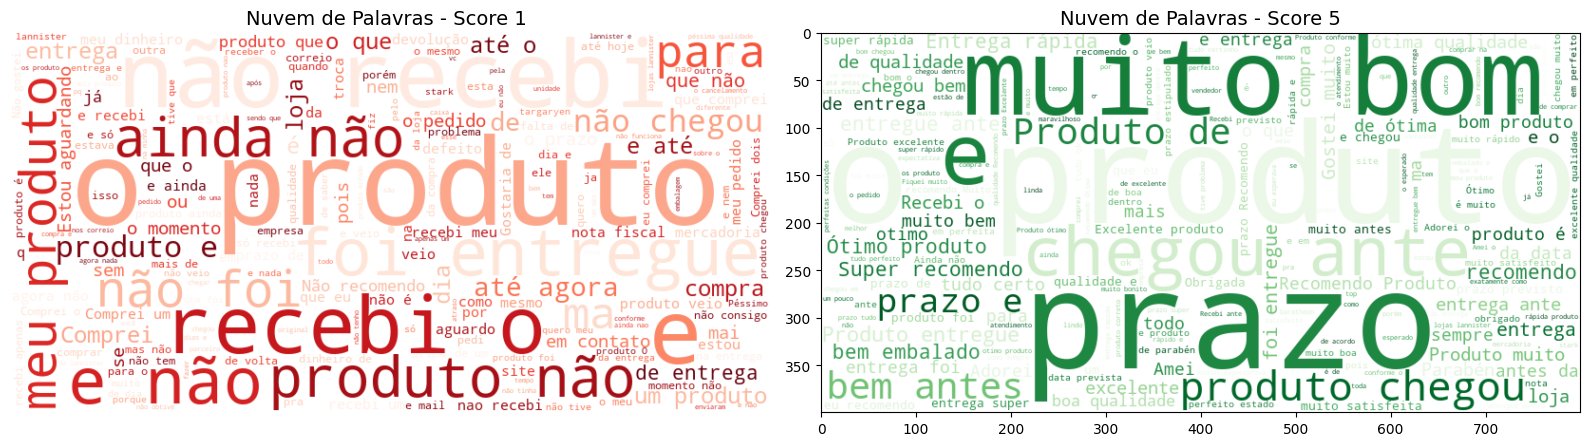

In [11]:
positive_comments = reviews[reviews['review_score'] == 5]['review_comment_message']
negative_comments = reviews[reviews['review_score'] == 1]['review_comment_message']


# Gera textos concatenados
text_n = ' '.join(negative_comments)
text_p = ' '.join(positive_comments)

# Gera as nuvens de palavras
wordcloud_negativo = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_n)
wordcloud_positivo = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(text_p)

# Plotando
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_negativo, interpolation='bilinear')
plt.title("Nuvem de Palavras - Score 1 ", fontsize=14)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_positivo, interpolation='bilinear')
plt.title("Nuvem de Palavras - Score 5", fontsize=14)

plt.tight_layout()
plt.show()

Com base na análise das nuvens de palavras, observamos que o score das avaliações está fortemente associado à experiência com o prazo de entrega, indicando que atrasos ou entregas dentro do esperado influenciam diretamente a satisfação dos clientes.

### Transformação de score para sentimento

In [12]:
# 1 e 2 = negativo (0), 3 = neutro (1), 4 e 5 = positivo (2)
def map_sentiment(score):
    if score in [1, 2]:
        return 0
    elif score == 3:
        return 1
    else:
        return 2

reviews['label'] = reviews['review_score'].apply(map_sentiment)
reviews = reviews[['review_comment_message', 'label']]

In [13]:
print(reviews['label'].value_counts())


label
2    26530
0    10890
1     3557
Name: count, dtype: int64


### Divisão de treino e teste

In [18]:
# Amostragem estratificada 
reviews_sampled, _ = train_test_split(
    reviews,
    train_size=1000,
    stratify=reviews['label'],
    random_state=42
)

#   Divisão entre treino e teste (80% treino / 20% teste)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    reviews_sampled['review_comment_message'].tolist(),
    reviews_sampled['label'].tolist(),
    test_size=0.2,
    stratify=reviews_sampled['label'],
    random_state=42
)

### Tokenização

In [26]:
#Vendo o número maximo de palavras em uma sentença
max_word_length = reviews['review_comment_message'].apply(lambda x: len(x.split())).max()
print("Comprimento máximo (palavras):", max_word_length)

Comprimento máximo (palavras): 42


In [34]:
tokenizer = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=43, return_tensors="tf")
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=43, return_tensors="tf")

In [28]:
#Vendo as setenças tonekizadas
print(train_encodings['input_ids'][:3]) 
print(test_encodings['input_ids'][:3]) 

[[101, 959, 22295, 13986, 117, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 7122, 279, 14188, 125, 10809, 2080, 1719, 19125, 2382, 106, 8911, 125, 230, 6650, 117, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 8169, 183, 7946, 106, 106, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
[[101, 2313, 179, 3859, 146, 18685, 2779, 3548, 247, 170, 20840, 2420, 122, 14619, 210, 260, 16302, 315, 119, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 7117, 3301, 146, 122, 118, 223, 215, 10573, 214, 176, 2779, 2663, 22283, 7343, 3576, 117, 240, 210, 770, 1367, 171, 6620, 125, 9358, 122, 744, 248, 16484, 2663, 22283, 7343, 3576, 117, 122, 1331, 179, 176, 2779, 346, 12304, 146, 102], [101, 2695, 1364, 146, 1673, 15212, 4063, 286, 1004, 117, 146, 3576, 3429, 170, 2455, 373, 119, 5645, 

In [29]:
# Criação dos datasets
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_labels
))

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    test_labels
))

### Baixando o modelo pré-treinado


In [30]:
model = TFBertForSequenceClassification.from_pretrained(
    "neuralmind/bert-base-portuguese-cased", 
    num_labels=3
)

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier', 'bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Treinando o modelo

Utilizamos o modelo neuralmind/bert-base-portuguese-cased com o otimizador Adam (taxa de aprendizado de 5e-5) e a função de perda SparseCategoricalCrossentropy, adequada para classificação multiclasse com rótulos inteiros. O treinamento foi realizado com batch size de 16 e apenas 1 época, visando economizar recursos computacionais. A métrica de accuracy foi utilizada para avaliar o desempenho geral do modelo na tarefa de classificação.

In [31]:
# Usa o otimizador Adam com uma taxa de aprendizado de 5e-5
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)

# Função de perda para problemas de classificação multiclasse
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Compila o modelo
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

# Treinamento do modelo
model.fit(
    train_dataset.batch(16),  # Batching de 16 amostras por iteração
    epochs=1,  # Realiza 1 época de treinamento
    validation_data=test_dataset.batch(16),  # Dados de validação também batched
    verbose=1   # Reduz a verbosidade para apenas mostrar uma linha por época
)

50/50 [==============================] - 463s 7s/step - loss: 0.5973 - accuracy: 0.7812 - val_loss: 0.4652 - val_accuracy: 0.8450


A acurácia obtida foi de 0.7812, o que indica que o modelo conseguiu classificar corretamente aproximadamente 78% dos exemplos no conjunto de teste. Esse resultado é satisfatório, especialmente considerando que o modelo foi treinado com uma quantidade reduzida de dados.

In [32]:
#Salvar o modelo 
model.save_pretrained("./sentiment_review_model")


### Predições

In [38]:
# Dicionário de entradas com os dados tokenizados
inputs = {
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"]
}
#Realiza predição com o input
outputs = model(inputs)
logits = outputs.logits
predicted_labels = tf.argmax(logits, axis=1).numpy()

In [39]:
for text, pred in zip(test_texts[:20], predicted_labels[:20]):  # mostra os 20 primeiros
    sentiment = ["Negativo", "Neutro", "Positivo"][pred]
    print(f"Texto: {text}\n→ Previsão: {sentiment}\n")


Texto: Assim que receber o item eu avalio com veracidade e tambem as recomendações.
→ Previsão: Positivo

Texto: Recebi o e-mail perguntando se eu recebi meu produto, porem já passou do prazo de entrega e ainda NÃO recebi meu produto, e diz que se eu não responder o e-mail seria dado como produto entregue.
→ Previsão: Negativo

Texto: Embora todo o processo tenho corrido bem, o produto veio com defeito. Farei a devolução no gatilho que não obstrui a passagem da água.
→ Previsão: Negativo

Texto: otimo
→ Previsão: Positivo

Texto: sim

→ Previsão: Positivo

Texto: Excelente produto entregue pela porcaria do correio brasileiro! Privatização já!
→ Previsão: Positivo

Texto: entrega rapida e dentro do prazo
→ Previsão: Positivo

Texto: ATÉ HJ NAO RECEBI MEU PRODUTO E NAO SEI SE AINDA VAI CHEGAR,NOS EMAIL ENVIADOS NAO DESCREVE CLARAMENTE NADA
→ Previsão: Negativo

Texto: Não obtive nenhuma resposta sobre o cartão stark
→ Previsão: Negativo

Texto: Excelente produto. 
→ Previsão: Positivo

T

### Conclusão

Este projeto visou desenvolver um modelo de classificação de sentimentos para analisar comentários de clientes no e-commerce brasileiro. Utilizando uma rede neural baseada no modelo BERT, as previsões foram realizadas para identificar sentimentos negativos, neutros e positivos nas avaliações. O modelo obteve uma acurácia de 78.12%, indicando um bom desempenho na tarefa. Essa solução pode ser aplicada para ajudar empresas a entender melhor o feedback dos consumidores, otimizando a gestão de reputação e melhorando a experiência do usuário no e-commerce.

Referências: (https://www.kaggle.com/code/rohitgadhwar/sentiment-analysis-using-transformers)
(https://www.kaggle.com/code/camillafonseca/nlp-an-lise-de-sentimento-do-olist-para-iniciantes)
(https://www.kaggle.com/code/wittmannf/machine-learning-p-an-lise-de-sentimentos-awari)
